In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv(r"C:\Users\Thummala Archana\OneDrive\Desktop\minor project FINAL\dataset\Hospital Clinical Deterioration.csv")
df

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417861,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,4,...,1.83,1.36,14.76,13.38,0.3906,62,F,1,ED,0
417862,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,1,...,1.71,1.35,14.75,13.29,0.4531,62,F,1,ED,0
417863,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,1,...,1.75,1.40,12.76,13.16,0.1993,62,F,1,ED,0
417864,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,3,...,1.64,1.39,14.96,13.14,0.5195,62,F,1,ED,0


In [4]:
df.columns  


Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type',
       'deterioration_next_12h'],
      dtype='object')

In [5]:
df.isnull().sum()

hour_from_admission       0
heart_rate                0
respiratory_rate          0
spo2_pct                  0
temperature_c             0
systolic_bp               0
diastolic_bp              0
oxygen_device             0
oxygen_flow               0
mobility_score            0
nurse_alert               0
wbc_count                 0
lactate                   0
creatinine                0
crp_level                 0
hemoglobin                0
sepsis_risk_score         0
age                       0
gender                    0
comorbidity_index         0
admission_type            0
deterioration_next_12h    0
dtype: int64

In [6]:
df.describe()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,comorbidity_index,deterioration_next_12h
count,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000
mean,24.098240,89.258118,20.177237,93.504918,36.968563,113.398465,70.516530,7.967031,2.283012,0.221243,9.198275,1.987468,1.318961,34.232249,13.279612,0.493449,53.863521,4.001931,0.054058
std,16.935515,21.127257,6.849362,5.950330,0.451594,17.107426,10.670383,16.248186,0.925933,0.415084,4.076129,1.511936,0.669615,36.282849,1.160177,0.222574,20.947460,2.602512,0.226132
min,0.000000,40.000000,8.000000,70.000000,35.240000,70.000000,40.000000,0.000000,0.000000,0.000000,2.000000,0.500000,0.400000,0.000000,7.000000,0.017600,18.000000,0.000000,0.000000
25%,10.000000,76.920000,15.860000,92.510000,36.700000,103.980000,65.020000,0.000000,2.000000,0.000000,7.000000,1.250000,0.970000,15.660000,12.680000,0.325500,36.000000,2.000000,0.000000
50%,21.000000,86.330000,19.330000,94.830000,36.920000,114.830000,71.470000,0.000000,2.000000,0.000000,8.490000,1.610000,1.190000,26.630000,13.360000,0.465850,54.000000,4.000000,0.000000
75%,36.000000,96.860000,23.040000,96.850000,37.150000,124.850000,77.440000,0.700000,3.000000,0.000000,10.160000,2.030000,1.430000,38.670000,14.020000,0.628400,72.000000,6.000000,0.000000
max,71.000000,180.000000,45.000000,100.000000,40.500000,184.560000,110.000000,56.190000,4.000000,1.000000,30.000000,8.000000,4.500000,250.000000,17.000000,0.999900,90.000000,8.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   hour_from_admission     417866 non-null  int64  
 1   heart_rate              417866 non-null  float64
 2   respiratory_rate        417866 non-null  float64
 3   spo2_pct                417866 non-null  float64
 4   temperature_c           417866 non-null  float64
 5   systolic_bp             417866 non-null  float64
 6   diastolic_bp            417866 non-null  float64
 7   oxygen_device           417866 non-null  object 
 8   oxygen_flow             417866 non-null  float64
 9   mobility_score          417866 non-null  int64  
 10  nurse_alert             417866 non-null  int64  
 11  wbc_count               417866 non-null  float64
 12  lactate                 417866 non-null  float64
 13  creatinine              417866 non-null  float64
 14  crp_level           

In [8]:
df.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0


In [9]:
df.tail()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
417861,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,4,...,1.83,1.36,14.76,13.38,0.3906,62,F,1,ED,0
417862,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,1,...,1.71,1.35,14.75,13.29,0.4531,62,F,1,ED,0
417863,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,1,...,1.75,1.40,12.76,13.16,0.1993,62,F,1,ED,0
417864,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,3,...,1.64,1.39,14.96,13.14,0.5195,62,F,1,ED,0
417865,28,93.46,20.76,94.83,36.42,119.53,71.02,none,0.0,2,...,1.59,1.37,12.98,13.09,0.5923,62,F,1,ED,0


In [10]:
df.deterioration_next_12h.unique()

array([0, 1], dtype=int64)

In [11]:
df['deterioration_next_12h'].value_counts()

deterioration_next_12h
0    395277
1     22589
Name: count, dtype: int64

In [12]:
df.select_dtypes(include='object').columns

Index(['oxygen_device', 'gender', 'admission_type'], dtype='object')

In [13]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

In [14]:
X = df_encoded.drop(columns=['deterioration_next_12h'])
y = df_encoded['deterioration_next_12h']


In [15]:
X = df_encoded.drop(columns=['deterioration_next_12h'])
y = df_encoded['deterioration_next_12h']

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

In [17]:
y_balanced.value_counts()

deterioration_next_12h
0    395277
1    395277
Name: count, dtype: int64

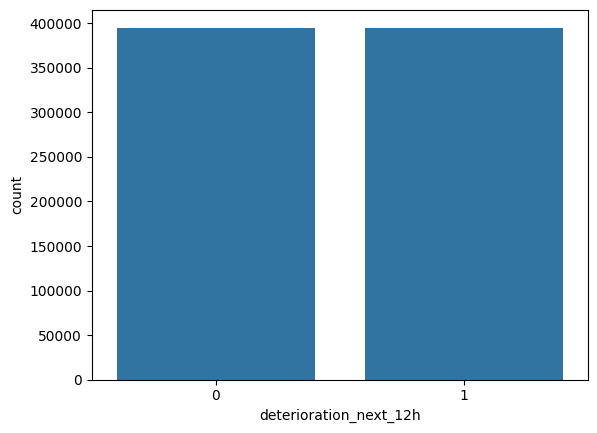

In [18]:
sns.countplot(x=y_balanced)
plt.show()

In [19]:
numeric_df = df_encoded.select_dtypes(include='number')

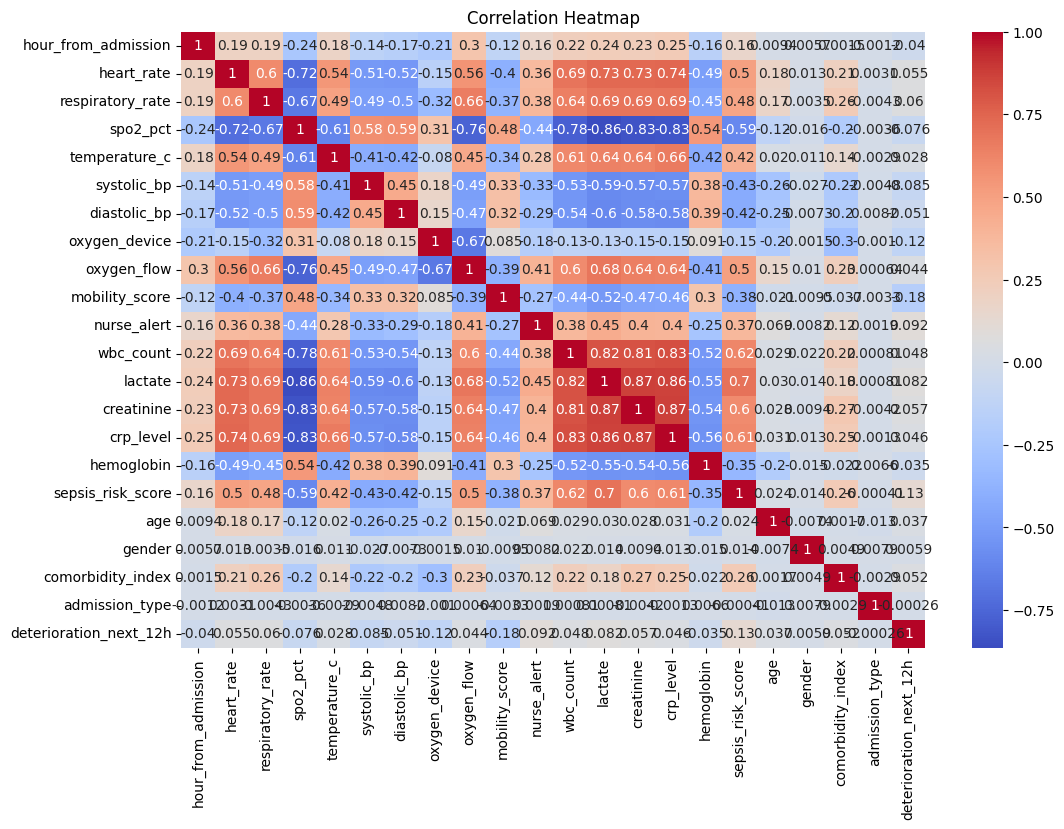

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [21]:
df.deterioration_next_12h.unique()

array([0, 1], dtype=int64)

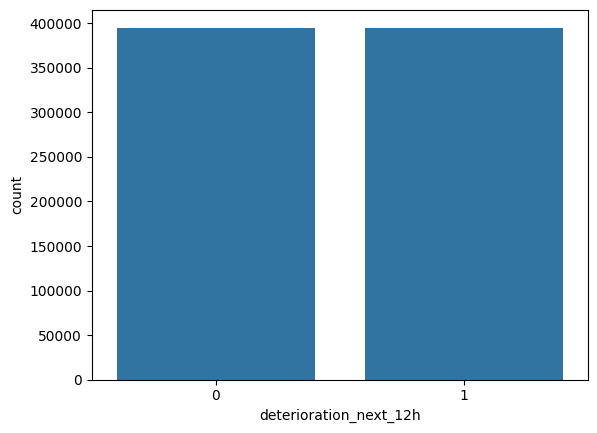

In [22]:
sns.countplot(x=y_balanced)
plt.show()

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [24]:
x_train.shape

(334292, 21)

In [25]:
x_test.shape

(83574, 21)

In [26]:
y_train.shape

(334292,)

In [27]:
y_test.shape

(83574,)

In [28]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []
labels = ['No Deterioration', 'Deterioration']

In [29]:
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype(int)
    predict = predict.astype(int)

    a = accuracy_score(testY, predict)
    p = precision_score(testY, predict)
    r = recall_score(testY, predict)
    f = f1_score(testY, predict)

    print(f"{algorithm} Accuracy  :", a)
    print(f"{algorithm} Precision :", p)
    print(f"{algorithm} Recall    :", r)
    print(f"{algorithm} F1-Score  :", f)

    labels = ['No Deterioration', 'Deterioration']
    print("\nClassification Report:\n")
    print(classification_report(testY, predict, target_names=labels))

    cm = confusion_matrix(testY, predict)
    print("Confusion Matrix:\n", cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{algorithm} Confusion Matrix")
    plt.show()


Isolation Forest Accuracy  : 0.894943403450834
Isolation Forest Precision : 0.0018899125915426411
Isolation Forest Recall    : 0.0017532325224632918
Isolation Forest F1-Score  : 0.0018190086402910413

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.94      0.95      0.94     79011
   Deterioration       0.00      0.00      0.00      4563

        accuracy                           0.89     83574
       macro avg       0.47      0.47      0.47     83574
    weighted avg       0.89      0.89      0.89     83574

Confusion Matrix:
 [[74786  4225]
 [ 4555     8]]


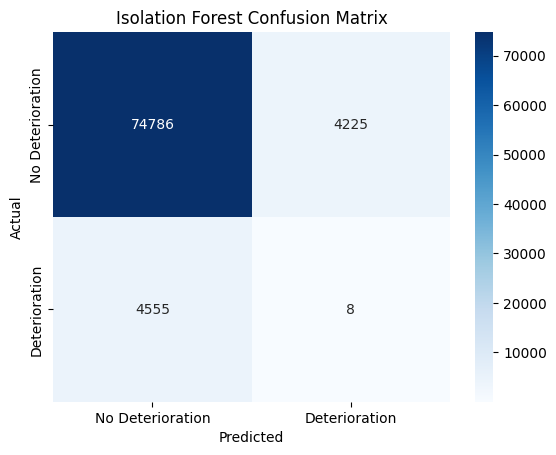

['IsolationForest_weights.pkl']

In [30]:
from sklearn.ensemble import IsolationForest
import numpy as np
import joblib

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(x_train)

iso_pred = iso_forest.predict(x_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

calculateMetrics("Isolation Forest", iso_pred, y_test)

joblib.dump(iso_forest, "IsolationForest_weights.pkl")


Bayesian Ridge Accuracy  : 0.9454016799483093
Bayesian Ridge Precision : 0.0
Bayesian Ridge Recall    : 0.0
Bayesian Ridge F1-Score  : 0.0

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.95      1.00      0.97     79011
   Deterioration       0.00      0.00      0.00      4563

        accuracy                           0.95     83574
       macro avg       0.47      0.50      0.49     83574
    weighted avg       0.89      0.95      0.92     83574

Confusion Matrix:
 [[79011     0]
 [ 4563     0]]


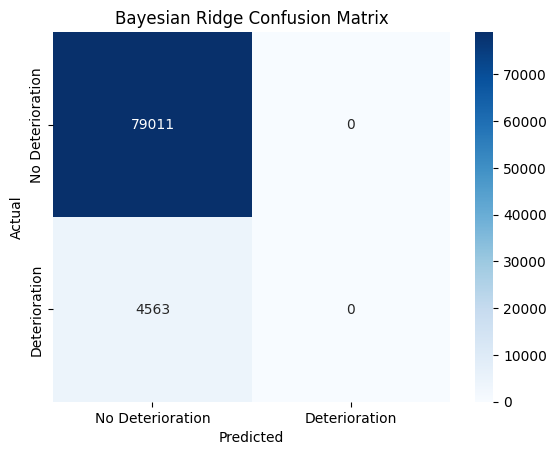

['BayesianRidge_weights.pkl']

In [31]:
from sklearn.linear_model import BayesianRidge
import numpy as np
import joblib

bayes_ridge = BayesianRidge()
bayes_ridge.fit(x_train, y_train)

y_pred_continuous = bayes_ridge.predict(x_test)
y_pred_bayes = (y_pred_continuous >= 0.5).astype(int)

calculateMetrics("Bayesian Ridge", y_pred_bayes, y_test)

joblib.dump(bayes_ridge, "BayesianRidge_weights.pkl")


Logistic Regression Accuracy  : 0.7490487472180343
Logistic Regression Precision : 0.14123305640577175
Logistic Regression Recall    : 0.7078676309445541
Logistic Regression F1-Score  : 0.23548281267087084

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.98      0.75      0.85     79011
   Deterioration       0.14      0.71      0.24      4563

        accuracy                           0.75     83574
       macro avg       0.56      0.73      0.54     83574
    weighted avg       0.93      0.75      0.82     83574

Confusion Matrix:
 [[59371 19640]
 [ 1333  3230]]


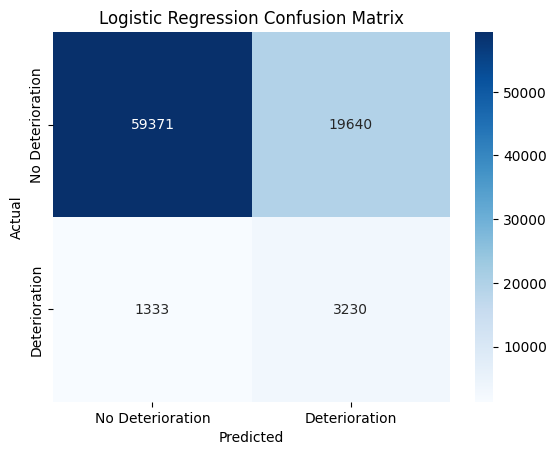

['LogisticRegression_weights.pkl']

In [32]:
from sklearn.linear_model import LogisticRegression
import joblib

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(x_train, y_train)

log_pred = log_reg.predict(x_test)

calculateMetrics("Logistic Regression", log_pred, y_test)

joblib.dump(log_reg, "LogisticRegression_weights.pkl")


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

Gradient Boosting Accuracy  : 0.9602029339268193
Gradient Boosting Precision : 0.7835855112333792
Gradient Boosting Recall    : 0.3745342976112207
Gradient Boosting F1-Score  : 0.5068208778173191

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.96      0.99      0.98     79011
   Deterioration       0.78      0.37      0.51      4563

        accuracy                           0.96     83574
       macro avg       0.87      0.68      0.74     83574
    weighted avg       0.96      0.96      0.95     83574

Confusion Matrix:
 [[78539   472]
 [ 2854  1709]]


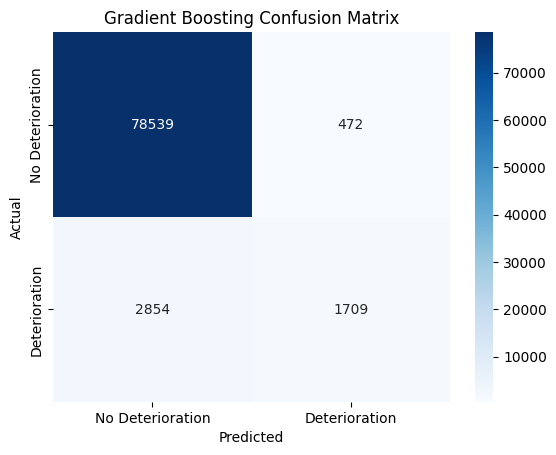

['GradientBoosting_weights.pkl']

In [54]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(x_train, y_train)
gb_pred = gb.predict(x_test)

calculateMetrics("Gradient Boosting", gb_pred, y_test)
joblib.dump(gb, "GradientBoosting_weights.pkl")


In [35]:
testdata = pd.read_csv(r"C:\Users\Thummala Archana\OneDrive\Desktop\minor project FINAL\dataset\test_patients.csv")
testdata 

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,5.68,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,5.46,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,5.55,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,5.50,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,5.96,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective
5,4,79.52,20.93,97.12,37.07,105.49,68.71,none,0.0,3,...,7.19,1.74,1.14,25.17,12.17,0.2644,74,F,3,Transfer
6,5,79.58,20.75,97.70,37.07,104.78,70.11,none,0.0,2,...,7.18,1.73,1.13,25.93,12.14,0.3890,74,F,3,Transfer
7,6,77.74,20.96,97.36,37.05,103.21,70.26,none,0.0,3,...,6.89,1.78,1.12,27.64,12.17,0.4677,74,F,3,Transfer
8,7,75.32,20.54,97.04,37.09,102.15,69.54,none,0.0,3,...,6.75,1.82,1.14,25.61,12.12,0.1783,74,F,3,Transfer
9,8,75.95,21.90,96.08,36.99,100.00,67.07,none,0.0,3,...,6.65,1.90,1.16,28.22,12.14,0.3958,74,F,3,Transfer


In [36]:
testdata.columns

Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type'],
      dtype='object')

In [37]:
testdata.isnull().sum()

hour_from_admission    0
heart_rate             0
respiratory_rate       0
spo2_pct               0
temperature_c          0
systolic_bp            0
diastolic_bp           0
oxygen_device          0
oxygen_flow            0
mobility_score         0
nurse_alert            0
wbc_count              0
lactate                0
creatinine             0
crp_level              0
hemoglobin             0
sepsis_risk_score      0
age                    0
gender                 0
comorbidity_index      0
admission_type         0
dtype: int64

In [38]:
testdata.describe()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,comorbidity_index
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.0,10.000000,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.000000,73.519000,17.809000,96.220000,37.147000,106.884000,73.438000,0.0,2.600000,0.0,6.281000,1.497000,1.188000,18.759000,12.873000,0.295650,49.000000,2.500000
std,2.581989,4.784383,3.424767,1.112005,0.105625,4.283486,4.731349,0.0,0.516398,0.0,0.718338,0.318505,0.055936,8.235492,0.766189,0.101141,26.352314,0.527046
min,0.000000,67.030000,13.870000,94.450000,36.990000,100.000000,67.070000,0.0,2.000000,0.0,5.460000,1.130000,1.120000,10.240000,12.120000,0.167800,24.000000,2.000000
25%,2.250000,69.055000,14.510000,95.327500,37.070000,103.602500,69.682500,0.0,2.000000,0.0,5.582500,1.202500,1.140000,10.905000,12.147500,0.212600,24.000000,2.000000
50%,4.000000,74.335000,18.080000,96.300000,37.135000,107.215000,72.865000,0.0,3.000000,0.0,6.305000,1.505000,1.185000,18.555000,12.830000,0.282200,49.000000,2.500000
75%,5.750000,77.292500,20.885000,97.100000,37.240000,110.605000,78.020000,0.0,3.000000,0.0,6.855000,1.770000,1.235000,25.850000,13.595000,0.375575,74.000000,3.000000
max,8.000000,79.580000,21.900000,97.700000,37.290000,111.730000,79.140000,0.0,3.000000,0.0,7.190000,1.900000,1.270000,28.220000,13.690000,0.467700,74.000000,3.000000


In [39]:
testdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   hour_from_admission  10 non-null     int64  
 1   heart_rate           10 non-null     float64
 2   respiratory_rate     10 non-null     float64
 3   spo2_pct             10 non-null     float64
 4   temperature_c        10 non-null     float64
 5   systolic_bp          10 non-null     float64
 6   diastolic_bp         10 non-null     float64
 7   oxygen_device        10 non-null     object 
 8   oxygen_flow          10 non-null     float64
 9   mobility_score       10 non-null     int64  
 10  nurse_alert          10 non-null     int64  
 11  wbc_count            10 non-null     float64
 12  lactate              10 non-null     float64
 13  creatinine           10 non-null     float64
 14  crp_level            10 non-null     float64
 15  hemoglobin           10 non-null     float6

In [40]:
testdata.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,5.68,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,5.46,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,5.55,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,5.50,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,5.96,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective


In [41]:
testdata.tail()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
5,4,79.52,20.93,97.12,37.07,105.49,68.71,none,0.0,3,...,7.19,1.74,1.14,25.17,12.17,0.2644,74,F,3,Transfer
6,5,79.58,20.75,97.70,37.07,104.78,70.11,none,0.0,2,...,7.18,1.73,1.13,25.93,12.14,0.3890,74,F,3,Transfer
7,6,77.74,20.96,97.36,37.05,103.21,70.26,none,0.0,3,...,6.89,1.78,1.12,27.64,12.17,0.4677,74,F,3,Transfer
8,7,75.32,20.54,97.04,37.09,102.15,69.54,none,0.0,3,...,6.75,1.82,1.14,25.61,12.12,0.1783,74,F,3,Transfer
9,8,75.95,21.90,96.08,36.99,100.00,67.07,none,0.0,3,...,6.65,1.90,1.16,28.22,12.14,0.3958,74,F,3,Transfer


In [42]:
testdata.select_dtypes(include='object').columns

Index(['oxygen_device', 'gender', 'admission_type'], dtype='object')

In [43]:
testdata_encoded = testdata.copy()

for col in testdata_encoded.select_dtypes(include='object').columns:
    testdata_encoded[col] = LabelEncoder().fit_transform(testdata_encoded[col])

In [44]:
# Create clean test data
testdata_clean = testdata.copy()

In [45]:
testdata_clean.columns

Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type'],
      dtype='object')

In [46]:
for col in ['oxygen_device', 'gender', 'admission_type']:
    print(col, testdata_clean[col].unique())

oxygen_device ['none']
gender ['M' 'F']
admission_type ['Elective' 'Transfer']


In [47]:
# FINAL FIX: convert categorical columns directly to numeric

testdata_clean['oxygen_device'] = 0
testdata_clean['gender'] = 0
testdata_clean['admission_type'] = 0

In [48]:
testdata_clean.dtypes

hour_from_admission      int64
heart_rate             float64
respiratory_rate       float64
spo2_pct               float64
temperature_c          float64
systolic_bp            float64
diastolic_bp           float64
oxygen_device            int64
oxygen_flow            float64
mobility_score           int64
nurse_alert              int64
wbc_count              float64
lactate                float64
creatinine             float64
crp_level              float64
hemoglobin             float64
sepsis_risk_score      float64
age                      int64
gender                   int64
comorbidity_index        int64
admission_type           int64
dtype: object

In [49]:
# Step 3: Align test data column order with training data
testdata_final = testdata_clean[X.columns]

In [50]:
print(list(testdata_final.columns) == list(X.columns))

True


In [51]:
# Final prediction
predictions = gb.predict(testdata_final)

predictions


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [52]:
testdata_final['prediction'] = [labels[i] for i in predictions]
testdata_final

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,prediction
0,0,68.58,14.47,96.52,37.18,108.94,78.43,0,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,0,2,0,No Deterioration
1,1,67.03,13.87,94.94,37.25,111.73,79.14,0,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,0,2,0,No Deterioration
2,2,69.05,14.63,94.45,37.29,111.48,78.86,0,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,0,2,0,No Deterioration
3,3,69.07,14.42,95.16,37.27,110.68,76.79,0,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,0,2,0,No Deterioration
4,4,73.35,15.62,95.83,37.21,110.38,75.47,0,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,0,2,0,No Deterioration
5,4,79.52,20.93,97.12,37.07,105.49,68.71,0,0.0,3,...,1.74,1.14,25.17,12.17,0.2644,74,0,3,0,No Deterioration
6,5,79.58,20.75,97.70,37.07,104.78,70.11,0,0.0,2,...,1.73,1.13,25.93,12.14,0.3890,74,0,3,0,No Deterioration
7,6,77.74,20.96,97.36,37.05,103.21,70.26,0,0.0,3,...,1.78,1.12,27.64,12.17,0.4677,74,0,3,0,No Deterioration
8,7,75.32,20.54,97.04,37.09,102.15,69.54,0,0.0,3,...,1.82,1.14,25.61,12.12,0.1783,74,0,3,0,No Deterioration
9,8,75.95,21.90,96.08,36.99,100.00,67.07,0,0.0,3,...,1.90,1.16,28.22,12.14,0.3958,74,0,3,0,No Deterioration
